# Fingerprint Enhancement System

Standalone notebook version. This notebook contains the complete experiment implementation locally and does not import project functions from the Python script.

## 1. Setup and Local Implementation

In [1]:
"""Complete BMDS2133 Fingerprint Enhancement System workflow.

This module is a complete standalone implementation:

* ``Fingerprint_Enhancement_System.py`` runs the full sequential workflow.
* ``Fingerprint_Enhancement_System.ipynb`` contains an equivalent local copy of
  the implementation and does not import this module.

The final grayscale recommendation is OpenCV Non-Local Means with h=0.06.
Structural analysis is deliberately separate from grayscale enhancement.
"""
from __future__ import annotations

import argparse
import importlib.util
import math
import platform
import subprocess
import sys
import warnings
from pathlib import Path
from time import perf_counter
from typing import Any


def _install_missing_runtime_packages() -> None:
    """Install missing third-party packages needed by this project."""
    required_packages = {
        "cv2": "opencv-python>=4.8,<5",
        "numpy": "numpy==1.26.4",
        "PIL": "pillow>=10,<12",
        "pandas": "pandas>=2.2,<3",
        "scipy": "scipy>=1.11,<2",
        "skimage": "scikit-image>=0.23,<0.26",
        "matplotlib": "matplotlib>=3.8,<4",
    }
    missing_packages = [
        package
        for import_name, package in required_packages.items()
        if importlib.util.find_spec(import_name) is None
    ]
    if not missing_packages:
        return
    print("Installing missing packages:", ", ".join(missing_packages))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])


_install_missing_runtime_packages()

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from scipy import ndimage as ndi, signal
from skimage import exposure, filters, measure, morphology, restoration, transform
from skimage.metrics import mean_squared_error, peak_signal_noise_ratio, structural_similarity

warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path.cwd().resolve()
DATASET_ROOT = PROJECT_ROOT / "data" / "SOCOFing"
REAL_DIR = DATASET_ROOT / "Real"
ALTERED_DIR = DATASET_ROOT / "Altered"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

IMAGE_SIZE = (256, 256)
SEED = 20260902
HOLDOUT_SEED = 20260903
NOISE_SEED_BASE = 20260903
ALTERED_SEED = 20260904
BENCHMARK_PSNR = 28.17
FINAL_NLM_H = 0.06
CONTROLLED_SEVERITY = 0.55
GAUSSIAN_SIGMA = 0.018 + 0.055 * CONTROLLED_SEVERITY
NLM_TEMPLATE_WINDOW_SIZE = 7
NLM_SEARCH_WINDOW_SIZE = 21
SUPPORTED_EXTENSIONS = {".bmp", ".png", ".jpg", ".jpeg", ".tif", ".tiff"}

FROZEN_HOLDOUT_NAMES = [
    "586__M_Right_middle_finger.BMP",
    "541__M_Left_thumb_finger.BMP",
    "15__F_Left_little_finger.BMP",
    "586__M_Left_little_finger.BMP",
    "176__M_Left_index_finger.BMP",
    "169__F_Left_little_finger.BMP",
    "67__F_Right_index_finger.BMP",
    "75__F_Right_thumb_finger.BMP",
    "61__M_Right_index_finger.BMP",
    "70__M_Right_index_finger.BMP",
    "39__M_Right_little_finger.BMP",
    "536__F_Left_index_finger.BMP",
    "415__M_Right_middle_finger.BMP",
    "159__M_Left_little_finger.BMP",
    "354__M_Left_thumb_finger.BMP",
    "434__M_Right_index_finger.BMP",
    "409__M_Left_index_finger.BMP",
    "40__F_Right_ring_finger.BMP",
    "207__M_Left_index_finger.BMP",
    "57__M_Right_ring_finger.BMP",
    "416__M_Left_thumb_finger.BMP",
    "344__M_Right_thumb_finger.BMP",
    "540__F_Right_index_finger.BMP",
    "184__M_Left_little_finger.BMP",
    "352__M_Right_ring_finger.BMP",
    "48__F_Left_little_finger.BMP",
    "99__M_Left_little_finger.BMP",
    "243__M_Right_index_finger.BMP",
    "529__M_Right_thumb_finger.BMP",
    "547__M_Left_thumb_finger.BMP",
    "38__M_Right_ring_finger.BMP",
    "214__M_Right_ring_finger.BMP",
    "236__M_Right_middle_finger.BMP",
    "451__M_Right_thumb_finger.BMP",
    "485__M_Left_little_finger.BMP",
    "520__M_Right_ring_finger.BMP",
    "336__M_Right_little_finger.BMP",
    "306__M_Left_middle_finger.BMP",
    "503__M_Left_thumb_finger.BMP",
    "468__F_Right_index_finger.BMP",
    "86__M_Right_middle_finger.BMP",
    "554__M_Left_index_finger.BMP",
    "189__F_Right_little_finger.BMP",
    "432__M_Left_middle_finger.BMP",
    "84__M_Right_middle_finger.BMP",
    "437__M_Left_thumb_finger.BMP",
    "472__M_Left_little_finger.BMP",
    "582__M_Right_little_finger.BMP",
    "460__M_Left_middle_finger.BMP",
    "242__M_Right_little_finger.BMP",
    "52__M_Right_ring_finger.BMP",
    "376__F_Right_little_finger.BMP",
    "254__M_Left_middle_finger.BMP",
    "594__M_Left_ring_finger.BMP",
    "160__M_Right_ring_finger.BMP",
    "225__M_Right_middle_finger.BMP",
    "453__F_Right_little_finger.BMP",
    "209__F_Left_ring_finger.BMP",
    "600__M_Left_thumb_finger.BMP",
    "88__F_Left_middle_finger.BMP",
    "567__M_Left_ring_finger.BMP",
    "542__M_Right_ring_finger.BMP",
    "318__F_Right_middle_finger.BMP",
    "527__M_Right_ring_finger.BMP",
    "567__M_Right_little_finger.BMP",
    "350__M_Right_index_finger.BMP",
    "94__M_Left_middle_finger.BMP",
    "545__M_Right_middle_finger.BMP",
    "351__M_Left_middle_finger.BMP",
    "581__F_Left_index_finger.BMP",
    "233__M_Left_little_finger.BMP",
    "348__F_Left_index_finger.BMP",
    "435__F_Left_ring_finger.BMP",
    "426__M_Right_little_finger.BMP",
    "194__M_Left_middle_finger.BMP",
    "410__M_Right_middle_finger.BMP",
    "411__M_Left_little_finger.BMP",
    "558__M_Right_ring_finger.BMP",
    "420__M_Left_middle_finger.BMP",
    "387__F_Left_index_finger.BMP",
    "305__M_Left_little_finger.BMP",
    "534__F_Right_ring_finger.BMP",
    "237__M_Left_middle_finger.BMP",
    "88__F_Right_ring_finger.BMP",
    "525__M_Right_ring_finger.BMP",
    "227__M_Left_ring_finger.BMP",
    "561__M_Left_ring_finger.BMP",
    "323__M_Right_middle_finger.BMP",
    "533__M_Right_thumb_finger.BMP",
    "2__F_Left_little_finger.BMP",
    "346__M_Left_ring_finger.BMP",
    "291__M_Right_little_finger.BMP",
    "9__M_Right_middle_finger.BMP",
    "294__M_Right_thumb_finger.BMP",
    "445__M_Right_ring_finger.BMP",
    "453__F_Right_thumb_finger.BMP",
    "239__M_Left_index_finger.BMP",
    "533__M_Left_little_finger.BMP",
    "98__M_Right_thumb_finger.BMP",
    "556__F_Left_little_finger.BMP",
]

COMPATIBILITY = {
    "C0 NLM": ("NLM",),
    "C1 TV -> NLM": ("TV", "NLM"),
    "C2 NLM -> Modified Gabor": ("NLM", "Gabor"),
    "C3 NLM -> Directional Diffusion": ("NLM", "Diffusion"),
    "C4 TV -> NLM -> Directional Diffusion": ("TV", "NLM", "Diffusion"),
}


def _metric_image(image: np.ndarray) -> np.ndarray:
    base = np.asarray(image, dtype=np.float32)
    return np.clip(np.nan_to_num(base, nan=0.0, posinf=1.0, neginf=0.0), 0.0, 1.0)


def normalise_image(image: np.ndarray, low_percentile: float = 1.0, high_percentile: float = 99.0) -> np.ndarray:
    """Percentile-normalize an image to float32 [0, 1]."""
    base = np.asarray(image, dtype=np.float32)
    low, high = np.percentile(base, [low_percentile, high_percentile])
    return _metric_image(base if high - low < 1e-8 else (base - low) / (high - low))


def preprocess_p0(image: np.ndarray, output_size: tuple[int, int] = IMAGE_SIZE) -> np.ndarray:
    """Neutral P0: grayscale, consistent resizing, and intensity normalization."""
    source = np.asarray(image)
    array = source
    if array.ndim == 3:
        array = cv2.cvtColor(array, cv2.COLOR_RGBA2GRAY if array.shape[2] == 4 else cv2.COLOR_RGB2GRAY)
    if array.ndim != 2:
        raise ValueError(f"Expected a 2-D grayscale or 3-D colour image, got {array.shape}.")
    array = array.astype(np.float32)
    if np.issubdtype(source.dtype, np.integer):
        array /= float(np.iinfo(source.dtype).max)
    elif array.max(initial=0.0) > 1.0:
        array /= 255.0
    if output_size and array.shape != tuple(output_size):
        array = transform.resize(array, output_size, anti_aliasing=True, preserve_range=True)
    return normalise_image(array)


def load_fingerprint(path: str | Path, output_size: tuple[int, int] = IMAGE_SIZE) -> np.ndarray:
    """Load a fingerprint using the exact validated P0 file path."""
    source = Path(path)
    if not source.is_file():
        raise FileNotFoundError(f"Fingerprint image not found: {source}")
    if source.suffix.lower() not in SUPPORTED_EXTENSIONS:
        raise ValueError(f"Unsupported image extension: {source.suffix}")
    with Image.open(source) as pil_image:
        image = np.asarray(pil_image.convert("L"), dtype=np.float32) / 255.0
    image = transform.resize(image, output_size, anti_aliasing=True, preserve_range=True)
    return normalise_image(image)


def apply_gaussian(image: np.ndarray, sigma: float = 0.65) -> np.ndarray:
    return _metric_image(ndi.gaussian_filter(_metric_image(image), sigma=float(sigma)))


def apply_median(image: np.ndarray, size: int = 3) -> np.ndarray:
    return _metric_image(ndi.median_filter(_metric_image(image), size=int(size)))


def apply_clahe(image: np.ndarray, clip_limit: float = 0.005, kernel_size: int = 32) -> np.ndarray:
    """Apply CLAHE as a conventional baseline."""
    return _metric_image(exposure.equalize_adapthist(_metric_image(image), clip_limit=clip_limit, kernel_size=kernel_size))


def apply_contrast_stretching(image: np.ndarray, low: float = 1.0, high: float = 99.0) -> np.ndarray:
    base = _metric_image(image)
    lo, hi = np.percentile(base, [low, high])
    return base.copy() if hi - lo < 1e-8 else _metric_image((base - lo) / (hi - lo))


def apply_nlm(image: np.ndarray, h: float = FINAL_NLM_H) -> np.ndarray:
    """Validated Member 1 wrapper: OpenCV NLM on normalised grayscale input."""
    base = _metric_image(image)
    as_uint8 = np.round(base * 255.0).astype(np.uint8)
    filtered = cv2.fastNlMeansDenoising(
        as_uint8,
        None,
        h=float(h) * 255.0,
        templateWindowSize=NLM_TEMPLATE_WINDOW_SIZE,
        searchWindowSize=NLM_SEARCH_WINDOW_SIZE,
    )
    return _metric_image(filtered.astype(np.float32) / 255.0)


def apply_tv_restoration(image: np.ndarray, weight: float = 0.02) -> np.ndarray:
    """Validated Member 3 wrapper around skimage total-variation restoration."""
    base = _metric_image(image)
    restored = restoration.denoise_tv_chambolle(base, weight=weight, channel_axis=None)
    return _metric_image(restored)


def _fingerprint_mask(image: np.ndarray, block_size: int = 17) -> np.ndarray:
    base = _metric_image(image)
    mean = ndi.uniform_filter(base, size=block_size, mode="reflect")
    std = np.sqrt(np.maximum(ndi.uniform_filter(base * base, size=block_size, mode="reflect") - mean * mean, 0))
    threshold = max(0.012, float(np.percentile(std, 70) * 0.55))
    mask = (std > threshold) | ((base < np.percentile(base, 92)) & (std > threshold * 0.55))
    mask = morphology.opening(morphology.closing(mask, morphology.disk(5)), morphology.disk(2))
    mask = ndi.binary_fill_holes(mask)
    mask = morphology.remove_small_holes(mask.astype(bool), area_threshold=600)
    return morphology.remove_small_objects(mask, min_size=600)


def _orientation_field(image: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    gx, gy = filters.sobel_h(image), filters.sobel_v(image)
    gxx, gyy = ndi.gaussian_filter(gx * gx, 2), ndi.gaussian_filter(gy * gy, 2)
    gxy = ndi.gaussian_filter(gx * gy, 2)
    orientation = 0.5 * np.arctan2(2 * gxy, gxx - gyy)
    coherence = np.sqrt((gxx - gyy) ** 2 + 4 * gxy ** 2) / (gxx + gyy + 1e-8)
    return orientation.astype(np.float32), coherence.astype(np.float32)


def estimate_orientation_field(
    image: np.ndarray,
    smoothing_sigma: float = 3.0,
    orientation_smoothing_sigma: float = 2.0,
) -> tuple[np.ndarray, np.ndarray]:
    """Estimate ridge orientation and coherence for Member 2 and Member 4."""
    base = _metric_image(image)
    gx, gy = filters.sobel_h(base), filters.sobel_v(base)
    gxx = ndi.gaussian_filter(gx * gx, smoothing_sigma)
    gyy = ndi.gaussian_filter(gy * gy, smoothing_sigma)
    gxy = ndi.gaussian_filter(gx * gy, smoothing_sigma)
    sin2 = ndi.gaussian_filter(2 * gxy, orientation_smoothing_sigma)
    cos2 = ndi.gaussian_filter(gxx - gyy, orientation_smoothing_sigma)
    orientation = 0.5 * np.arctan2(sin2, cos2)
    coherence = np.sqrt((gxx - gyy) ** 2 + 4 * gxy**2) / (gxx + gyy + 1e-8)
    return orientation.astype(np.float32), coherence.astype(np.float32)


def estimate_local_frequency_map(
    image: np.ndarray,
    mask: np.ndarray,
    block_size: int = 32,
    frequencies: tuple[float, ...] = (0.075, 0.095, 0.115, 0.140),
) -> tuple[np.ndarray, np.ndarray]:
    """Select among fixed ridge-frequency candidates per local block."""
    base = _metric_image(image)
    mask = np.asarray(mask, bool)
    freq_map = np.full_like(base, float(np.median(frequencies)), dtype=np.float32)
    confidence = np.zeros_like(base, dtype=np.float32)
    window = np.outer(np.hanning(block_size), np.hanning(block_size))
    yy, xx = np.mgrid[-block_size // 2 : block_size // 2, -block_size // 2 : block_size // 2]
    radius = np.sqrt(xx**2 + yy**2)
    center_exclusion = radius <= 2
    for row in range(0, base.shape[0] - block_size + 1, block_size // 2):
        for col in range(0, base.shape[1] - block_size + 1, block_size // 2):
            block_mask = mask[row : row + block_size, col : col + block_size]
            if float(np.mean(block_mask)) < 0.25:
                continue
            block = base[row : row + block_size, col : col + block_size]
            if float(np.std(block[block_mask])) < 0.012:
                continue
            spectrum = np.abs(np.fft.fftshift(np.fft.fft2((block - np.mean(block[block_mask])) * window)))
            spectrum[center_exclusion] = 0
            peak = np.unravel_index(int(np.argmax(spectrum)), spectrum.shape)
            observed = float(radius[peak] / block_size)
            nearest = min(frequencies, key=lambda frequency: abs(frequency - observed))
            conf = float(np.max(spectrum) / (np.mean(spectrum) + 1e-8))
            region = np.s_[row : row + block_size, col : col + block_size]
            freq_map[region] = nearest
            confidence[region] = max(float(np.mean(confidence[region])), min(conf / 25, 1))
    return freq_map, confidence


def apply_modified_gabor(
    image: np.ndarray,
    frequencies: tuple[float, ...] = (0.075, 0.095, 0.115, 0.140),
    orientation_bins: int = 8,
    blend: float = 0.18,
) -> np.ndarray:
    """Validated Member 2 modified Gabor: orientation-adaptive local ridge filtering."""
    base = _metric_image(image)
    mask = _fingerprint_mask(base)
    orientation, coherence = estimate_orientation_field(base)
    freq_map, freq_conf = estimate_local_frequency_map(base, mask, frequencies=frequencies)
    bins = np.linspace(0, np.pi, orientation_bins, endpoint=False)
    oi = np.argmin(np.abs(np.angle(np.exp(1j * (orientation[..., None] - bins[None, None, :])))), axis=2)
    fi = np.argmin(np.abs(freq_map[..., None] - np.asarray(frequencies)[None, None, :]), axis=2)
    selected = np.zeros_like(base, dtype=np.float32)
    inverted = 1 - base
    for f_index, frequency in enumerate(frequencies):
        for o_index, theta in enumerate(bins):
            real, imag = filters.gabor(inverted, frequency=float(frequency), theta=float(theta), bandwidth=1.8)
            response = np.sqrt(real**2 + imag**2)
            selector = (oi == o_index) & (fi == f_index) & mask
            selected[selector] = response[selector]
    ridge = np.where(mask, 1 - normalise_image(selected), base)
    confidence_weight = np.clip(0.30 + 0.70 * coherence, 0, 1) * np.clip(0.40 + 0.60 * freq_conf, 0, 1)
    weight = blend * confidence_weight * mask
    return _metric_image((1 - weight) * base + weight * ridge)


def apply_ordinary_gabor(image: np.ndarray, frequency: float = 0.115, orientations: int = 8, blend: float = 0.30) -> np.ndarray:
    base = _metric_image(image)
    responses = []
    for theta in np.linspace(0, np.pi, orientations, endpoint=False):
        real, imag = filters.gabor(1 - base, frequency=frequency, theta=theta)
        responses.append(np.sqrt(real**2 + imag**2))
    return _metric_image((1 - blend) * base + blend * (1 - normalise_image(np.max(responses, axis=0))))


def apply_wiener(image: np.ndarray, window_size: int = 5) -> np.ndarray:
    return _metric_image(signal.wiener(_metric_image(image), mysize=window_size))


def _oriented_kernel(theta: float) -> np.ndarray:
    axis = np.arange(9, dtype=np.float32) - 4
    xx, yy = np.meshgrid(axis, axis)
    c, s = math.cos(theta), math.sin(theta)
    xr, yr = c * xx + s * yy, -s * xx + c * yy
    kernel = np.exp(-(xr**2 / (2 * 1.35**2) + yr**2 / (2 * 0.50**2)))
    return (kernel / kernel.sum()).astype(np.float32)


def apply_coherence_guided_directional_diffusion(
    image: np.ndarray,
    iterations: int = 4,
    step: float = 0.16,
) -> np.ndarray:
    """Validated Member 4 iterative coherence-guided directional diffusion."""
    current = _metric_image(image)
    mask = _fingerprint_mask(current)
    bins = np.linspace(0, np.pi, 8, endpoint=False)
    for _ in range(iterations):
        orientation, coherence = estimate_orientation_field(current)
        indexes = np.argmin(np.abs(np.angle(np.exp(1j * (orientation[..., None] - bins[None, None, :])))), axis=2)
        smoothed = np.zeros_like(current)
        for index, theta in enumerate(bins):
            conv = ndi.convolve(current, _oriented_kernel(theta), mode="reflect")
            smoothed[indexes == index] = conv[indexes == index]
        weight = np.clip(coherence, 0, 1) * mask
        current = _metric_image((1 - step * weight) * current + step * weight * smoothed)
    return current


def segment_fingerprint(image: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    base = _metric_image(image)
    mask = _fingerprint_mask(base)
    return (base < filters.threshold_sauvola(base, window_size=25, k=0.16)) & mask, mask


def morphological_cleanup(binary: np.ndarray, min_size: int = 24) -> np.ndarray:
    cleaned = morphology.closing(np.asarray(binary, bool), morphology.disk(1))
    return morphology.remove_small_objects(morphology.remove_small_holes(cleaned, area_threshold=28), min_size=min_size)


def thin_ridges(binary: np.ndarray) -> np.ndarray:
    return morphology.skeletonize(np.asarray(binary, bool))


def medial_axis_analysis(binary: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    return morphology.medial_axis(np.asarray(binary, bool), return_distance=True)


def extract_minutiae_detections(
    skeleton: np.ndarray,
    mask: np.ndarray | None = None,
    border_margin: int = 8,
) -> dict[str, np.ndarray]:
    skel = np.asarray(skeleton, bool)
    padded = np.pad(skel, 1)
    neighbours = [
        padded[:-2, 1:-1],
        padded[:-2, 2:],
        padded[1:-1, 2:],
        padded[2:, 2:],
        padded[2:, 1:-1],
        padded[2:, :-2],
        padded[1:-1, :-2],
        padded[:-2, :-2],
    ]
    crossing = np.sum(np.abs(np.diff(np.stack(neighbours + [neighbours[0]]).astype(np.int8), axis=0)), axis=0) / 2
    valid = skel.copy()
    valid[:border_margin] = False
    valid[-border_margin:] = False
    valid[:, :border_margin] = False
    valid[:, -border_margin:] = False
    if mask is not None and np.any(mask):
        valid &= morphology.binary_erosion(np.asarray(mask, bool), morphology.disk(border_margin))
    return {
        "ridge_endings": np.argwhere(valid & (crossing == 1)),
        "bifurcations": np.argwhere(valid & (crossing == 3)),
    }


def calculate_mse(reference: np.ndarray, candidate: np.ndarray) -> float:
    return float(mean_squared_error(_metric_image(reference), _metric_image(candidate)))


def calculate_psnr(reference: np.ndarray, candidate: np.ndarray) -> float:
    return float(peak_signal_noise_ratio(_metric_image(reference), _metric_image(candidate), data_range=1.0))


def calculate_ssim(reference: np.ndarray, candidate: np.ndarray) -> float:
    return float(structural_similarity(_metric_image(reference), _metric_image(candidate), data_range=1.0))


def calculate_ridge_coherence(image: np.ndarray, mask: np.ndarray | None = None) -> float:
    _, coherence = _orientation_field(_metric_image(image))
    region = _fingerprint_mask(image) if mask is None else mask
    return float(np.mean(coherence[region])) if np.any(region) else float(np.mean(coherence))


def calculate_local_contrast(image: np.ndarray, mask: np.ndarray | None = None, size: int = 17) -> float:
    base = _metric_image(image)
    mean = ndi.uniform_filter(base, size=size, mode="reflect")
    std = np.sqrt(np.maximum(ndi.uniform_filter(base * base, size=size, mode="reflect") - mean * mean, 0))
    region = _fingerprint_mask(base) if mask is None else mask
    return float(np.mean(std[region])) if np.any(region) else float(np.mean(std))


def calculate_fragmentation(image: np.ndarray) -> float:
    ridges, _ = segment_fingerprint(image)
    _, count = ndi.label(ridges)
    return float(count * 1000 / max(np.count_nonzero(ridges), 1))


def structural_metrics(image: np.ndarray) -> dict[str, float]:
    base = _metric_image(image)
    mask = _fingerprint_mask(base)
    local_mean = ndi.uniform_filter(base, 17, mode="reflect")
    local_std = np.sqrt(np.maximum(ndi.uniform_filter(base * base, 17, mode="reflect") - local_mean * local_mean, 0))
    binary, _ = segment_fingerprint(base)
    labels = measure.label(binary, connectivity=2)
    props = measure.regionprops(labels)
    skeleton = morphology.skeletonize(binary)
    points = extract_minutiae_detections(skeleton, mask)
    ridge_pixels = max(int(binary.sum()), 1)
    endpoints = len(points["ridge_endings"])
    return {
        "coherence": calculate_ridge_coherence(base, mask),
        "contrast": float(local_std[mask].mean()) if mask.any() else float(local_std.mean()),
        "fragmentation": len(props) / (ridge_pixels / 1000.0),
        "continuity": float(skeleton.sum()) / max(endpoints, 1),
        "ridge_coverage": float(binary.sum()) / max(float(mask.sum()), 1.0),
    }


def full_reference(reference: np.ndarray, candidate: np.ndarray) -> dict[str, float]:
    return {
        "mse": calculate_mse(reference, candidate),
        "psnr": calculate_psnr(reference, candidate),
        "ssim": calculate_ssim(reference, candidate),
    }


def controlled_degradation(clean: np.ndarray, seed: int) -> np.ndarray:
    rng = np.random.default_rng(int(seed))
    return _metric_image(clean + rng.normal(0.0, GAUSSIAN_SIGMA, clean.shape))


def demo_reference_metrics(reference: np.ndarray, images: dict[str, np.ndarray]) -> pd.DataFrame:
    rows = []
    for label, image in images.items():
        rows.append(
            {
                "candidate": label,
                "mse": calculate_mse(reference, image),
                "psnr": calculate_psnr(reference, image),
                "ssim": calculate_ssim(reference, image),
                "coherence": calculate_ridge_coherence(image),
                "local_contrast": calculate_local_contrast(image),
                "fragmentation": calculate_fragmentation(image),
            }
        )
    return pd.DataFrame(rows)


def enhance_fingerprint(
    image: np.ndarray,
    method: str = "nlm",
    *,
    assume_preprocessed: bool = False,
    **kwargs: Any,
) -> tuple[np.ndarray, dict[str, Any]]:
    """GUI-ready enhancement dispatcher returning image and processing metadata."""
    base = _metric_image(image) if assume_preprocessed else preprocess_p0(image)
    methods = {
        "nlm": apply_nlm,
        "modified_gabor": apply_modified_gabor,
        "tv": apply_tv_restoration,
        "directional_diffusion": apply_coherence_guided_directional_diffusion,
        "gaussian": apply_gaussian,
        "median": apply_median,
        "clahe": apply_clahe,
        "contrast_stretching": apply_contrast_stretching,
        "ordinary_gabor": apply_ordinary_gabor,
        "wiener": apply_wiener,
    }
    key = method.lower().strip()
    if key not in methods:
        raise ValueError(f"Unknown method '{method}'. Available: {', '.join(sorted(methods))}")
    enhanced = methods[key](base, **kwargs)
    metadata: dict[str, Any] = {
        "method": key,
        "preprocessing": "P0 already supplied" if assume_preprocessed else "P0",
        "input_shape": tuple(base.shape),
        "output_shape": tuple(enhanced.shape),
        "dtype": str(enhanced.dtype),
    }
    if key == "nlm":
        metadata.update(
            {
                "recommended": True,
                "h_normalized": float(kwargs.get("h", FINAL_NLM_H)),
                "backend": "cv2.fastNlMeansDenoising",
                "template_window_size": NLM_TEMPLATE_WINDOW_SIZE,
                "search_window_size": NLM_SEARCH_WINDOW_SIZE,
            }
        )
    return enhanced, metadata


def apply_final_enhancement(image: np.ndarray, *, assume_preprocessed: bool = False) -> tuple[np.ndarray, dict[str, Any]]:
    """Apply the frozen final recommendation: OpenCV NLM, h=0.06."""
    return enhance_fingerprint(image, "nlm", assume_preprocessed=assume_preprocessed, h=FINAL_NLM_H)


def list_images(folder: str | Path) -> list[Path]:
    source = Path(folder)
    if not source.is_dir():
        return []
    return sorted(
        (path for path in source.iterdir() if path.is_file() and path.suffix.lower() in SUPPORTED_EXTENSIONS),
        key=lambda path: path.name.lower(),
    )


def discover_dataset(root: str | Path = PROJECT_ROOT) -> dict[str, list[Path]]:
    project_root = Path(root).resolve()
    data = project_root / "data" / "SOCOFing"
    real_dir = data / "Real"
    altered_dir = data / "Altered"
    if not data.is_dir():
        raise FileNotFoundError("SOCOFing dataset not found under data/SOCOFing.")
    return {
        "Real": list_images(real_dir),
        "Easy": list_images(altered_dir / "Altered-Easy"),
        "Medium": list_images(altered_dir / "Altered-Medium"),
        "Hard": list_images(altered_dir / "Altered-Hard"),
    }


def dataset_inventory(dataset_paths: dict[str, list[Path]], root: str | Path = PROJECT_ROOT) -> pd.DataFrame:
    project_root = Path(root).resolve()
    return pd.DataFrame(
        [
            {
                "split": split,
                "count": len(paths),
                "representative_path": str(paths[0].relative_to(project_root)) if paths else "",
            }
            for split, paths in dataset_paths.items()
        ]
    )


def select_development_paths(real_paths: list[Path]) -> list[Path]:
    rng = np.random.default_rng(SEED)
    indices = np.arange(len(real_paths))
    rng.shuffle(indices)
    return [real_paths[int(index)] for index in indices[:12]]


def select_holdout_paths(real_dir: str | Path = REAL_DIR) -> list[Path]:
    paths = [Path(real_dir) / name for name in FROZEN_HOLDOUT_NAMES]
    if len(paths) != 100 or not all(path.is_file() for path in paths):
        raise FileNotFoundError("Frozen 100-image holdout selection is incomplete.")
    return paths


def select_canonical_500_paths(real_paths: list[Path]) -> list[Path]:
    paths = list(real_paths[:500])
    if len(paths) != 500 or len(set(paths)) != 500 or not all(path.is_file() for path in paths):
        raise FileNotFoundError("Canonical 500-image Real validation selection is incomplete.")
    return paths


def select_altered_paths(dataset_paths: dict[str, list[Path]]) -> dict[str, list[Path]]:
    selected: dict[str, list[Path]] = {}
    for offset, severity in enumerate(("Easy", "Medium", "Hard")):
        candidates = dataset_paths[severity]
        if len(candidates) < 500:
            raise FileNotFoundError(f"Need at least 500 Altered-{severity} images.")
        rng = np.random.default_rng(ALTERED_SEED + offset)
        selected[severity] = [candidates[int(index)] for index in rng.permutation(len(candidates))[:500]]
    return selected


def member_methods() -> dict[str, Any]:
    return {
        "M1 NLM": lambda image: apply_nlm(image, FINAL_NLM_H),
        "M2 Modified Gabor": lambda image: apply_modified_gabor(image),
        "M3 TV": lambda image: apply_tv_restoration(image, 0.02),
        "M4 Directional Diffusion": lambda image: apply_coherence_guided_directional_diffusion(image, 4, 0.16),
    }


def run_member_comparison(development_paths: list[Path], progress: bool = False) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows: list[dict[str, Any]] = []
    methods = member_methods()
    for i, path in enumerate(development_paths):
        if progress:
            print(f"  Member comparison image {i + 1}/{len(development_paths)}: {path.name}", flush=True)
        clean = load_fingerprint(path)
        degraded = controlled_degradation(clean, SEED + i)
        for name, method in methods.items():
            rows.append({"image": path.name, "method": name, **full_reference(clean, method(degraded))})
    per_image = pd.DataFrame(rows)
    summary = (
        per_image.groupby("method")
        .agg(
            images=("image", "count"),
            PSNR_mean=("psnr", "mean"),
            PSNR_std=("psnr", "std"),
            MSE_mean=("mse", "mean"),
            MSE_std=("mse", "std"),
            SSIM_mean=("ssim", "mean"),
            SSIM_std=("ssim", "std"),
        )
        .sort_values("PSNR_mean", ascending=False)
        .reset_index()
    )
    return per_image, summary


def apply_stages(image: np.ndarray, stages: tuple[str, ...]) -> np.ndarray:
    output = image
    for stage in stages:
        output = {
            "NLM": lambda data: apply_nlm(data, FINAL_NLM_H),
            "TV": lambda data: apply_tv_restoration(data, 0.02),
            "Gabor": apply_modified_gabor,
            "Diffusion": lambda data: apply_coherence_guided_directional_diffusion(data, 4, 0.16),
        }[stage](output)
    return output


def run_compatibility_study(development_paths: list[Path], progress: bool = False) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows: list[dict[str, Any]] = []
    for i, path in enumerate(development_paths):
        if progress:
            print(f"  Compatibility image {i + 1}/{len(development_paths)}: {path.name}", flush=True)
        clean = load_fingerprint(path)
        degraded = controlled_degradation(clean, SEED + i)
        for name, stages in COMPATIBILITY.items():
            rows.append({"image": path.name, "candidate": name, **full_reference(clean, apply_stages(degraded, stages))})
    per_image = pd.DataFrame(rows)
    summary = (
        per_image.groupby("candidate")
        .agg(
            images=("image", "count"),
            PSNR_mean=("psnr", "mean"),
            PSNR_std=("psnr", "std"),
            MSE_mean=("mse", "mean"),
            SSIM_mean=("ssim", "mean"),
        )
        .sort_values("PSNR_mean", ascending=False)
        .reset_index()
    )
    return per_image, summary


def controlled_validation(paths: list[Path], seed_base: int, progress_label: str | None = None) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    total = len(paths)
    for i, path in enumerate(paths):
        if progress_label and (i == 0 or (i + 1) % 50 == 0 or i + 1 == total):
            print(f"  {progress_label}: {i + 1}/{total}", flush=True)
        clean = load_fingerprint(path)
        degraded = controlled_degradation(clean, seed_base + i)
        enhanced = apply_nlm(degraded, FINAL_NLM_H)
        before = full_reference(clean, degraded)
        after = full_reference(clean, enhanced)
        rows.append(
            {
                "filename": path.name,
                "noise_seed": seed_base + i,
                **{f"degraded_{key}": value for key, value in before.items()},
                **{f"enhanced_{key}": value for key, value in after.items()},
                **{f"delta_{key}": after[key] - before[key] for key in before},
                "above_28_17": after["psnr"] > BENCHMARK_PSNR,
            }
        )
    return pd.DataFrame(rows)


def summarize_holdout(results: pd.DataFrame) -> pd.DataFrame:
    return results.agg(
        {
            "degraded_psnr": ["mean", "std"],
            "enhanced_psnr": ["mean", "std", "median", "min", "max"],
            "enhanced_mse": ["mean"],
            "enhanced_ssim": ["mean"],
            "delta_psnr": ["mean"],
            "delta_mse": ["mean"],
            "delta_ssim": ["mean"],
        }
    )


def summarize_large_validation(results: pd.DataFrame) -> dict[str, Any]:
    stats = {
        "count": len(results),
        "mean_psnr": results.enhanced_psnr.mean(),
        "std_psnr": results.enhanced_psnr.std(),
        "median_psnr": results.enhanced_psnr.median(),
        "min_psnr": results.enhanced_psnr.min(),
        "max_psnr": results.enhanced_psnr.max(),
        "mean_mse": results.enhanced_mse.mean(),
        "mean_ssim": results.enhanced_ssim.mean(),
        "above_28_17": int(results.above_28_17.sum()),
    }
    stats["percentage_above_28_17"] = 100 * stats["above_28_17"] / stats["count"]
    stats["margin_to_benchmark"] = stats["mean_psnr"] - BENCHMARK_PSNR
    return stats


def run_altered_validation(
    selected_altered: dict[str, list[Path]],
    progress: bool = False,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows: list[dict[str, Any]] = []
    for severity in ("Easy", "Medium", "Hard"):
        paths = selected_altered[severity]
        for i, path in enumerate(paths):
            if progress and (i == 0 or (i + 1) % 100 == 0 or i + 1 == len(paths)):
                print(f"  Altered-{severity}: {i + 1}/{len(paths)}", flush=True)
            before = load_fingerprint(path)
            after = apply_nlm(before, FINAL_NLM_H)
            before_metrics = structural_metrics(before)
            after_metrics = structural_metrics(after)
            rows.append(
                {
                    "severity": severity,
                    "filename": path.name,
                    **{f"{key}_before": value for key, value in before_metrics.items()},
                    **{f"{key}_after": value for key, value in after_metrics.items()},
                    **{f"delta_{key}": after_metrics[key] - before_metrics[key] for key in before_metrics},
                }
            )
    results = pd.DataFrame(rows)
    summary_rows = []
    groups = [(severity, results[results.severity.eq(severity)]) for severity in ("Easy", "Medium", "Hard")]
    groups.append(("Overall", results))
    metric_prefixes = ("coherence_", "contrast_", "fragmentation_", "continuity_", "ridge_coverage_", "delta_")
    for label, group in groups:
        summary_rows.append(
            {
                "severity": label,
                "count": len(group),
                **{f"mean_{column}": group[column].mean() for column in group.columns if column.startswith(metric_prefixes)},
            }
        )
    return results, pd.DataFrame(summary_rows)


def run_equivalence_probe(paths: list[Path], output_path: str | Path) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    arrays: dict[str, np.ndarray] = {}
    for i, path in enumerate(paths[:3]):
        clean = load_fingerprint(path)
        degraded = controlled_degradation(clean, NOISE_SEED_BASE + i)
        enhanced = apply_nlm(degraded, FINAL_NLM_H)
        arrays[f"clean_{i}"] = clean
        arrays[f"degraded_{i}"] = degraded
        arrays[f"enhanced_{i}"] = enhanced
        rows.append({"filename": path.name, **full_reference(clean, enhanced)})
    np.savez_compressed(output_path, **arrays)
    return pd.DataFrame(rows)


def save_table(df: pd.DataFrame, output_dir: str | Path, filename: str) -> Path:
    path = Path(output_dir) / filename
    df.to_csv(path, index=False)
    return path


def save_indexed_table(df: pd.DataFrame, output_dir: str | Path, filename: str) -> Path:
    path = Path(output_dir) / filename
    df.to_csv(path)
    return path


def plot_dataset_inventory(dataset_paths: dict[str, list[Path]], output_dir: str | Path, prefix: str) -> Path:
    fig, axes = plt.subplots(1, 4, figsize=(13, 3))
    for ax, (name, paths) in zip(axes, dataset_paths.items()):
        ax.imshow(Image.open(paths[0]).convert("L"), cmap="gray")
        ax.set_title(name)
        ax.axis("off")
    fig.tight_layout()
    path = Path(output_dir) / f"{prefix}_dataset_inventory.png"
    fig.savefig(path, dpi=160)
    return path


def plot_member_summary(member_summary: pd.DataFrame, output_dir: str | Path, prefix: str) -> Path:
    ax = member_summary.plot.bar(
        x="method",
        y="PSNR_mean",
        yerr="PSNR_std",
        legend=False,
        figsize=(8, 4),
        ylabel="PSNR (dB)",
        title="Frozen four-member comparison",
    )
    ax.axhline(BENCHMARK_PSNR, color="red", ls="--")
    fig = ax.get_figure()
    fig.tight_layout()
    path = Path(output_dir) / f"{prefix}_member_comparison_psnr.png"
    fig.savefig(path, dpi=160)
    return path


def plot_compatibility_summary(compat_summary: pd.DataFrame, output_dir: str | Path, prefix: str) -> Path:
    ax = compat_summary.plot.bar(
        x="candidate",
        y="PSNR_mean",
        legend=False,
        figsize=(9, 4),
        ylabel="PSNR (dB)",
        title="Compatibility candidates",
    )
    fig = ax.get_figure()
    fig.tight_layout()
    path = Path(output_dir) / f"{prefix}_compatibility_psnr.png"
    fig.savefig(path, dpi=160)
    return path


def plot_representative_results(
    large_paths: list[Path],
    selected_altered: dict[str, list[Path]],
    output_dir: str | Path,
    prefix: str,
) -> list[Path]:
    saved: list[Path] = []
    clean = load_fingerprint(large_paths[0])
    degraded = controlled_degradation(clean, NOISE_SEED_BASE)
    enhanced = apply_nlm(degraded, FINAL_NLM_H)
    fig, axes = plt.subplots(1, 3, figsize=(10, 3))
    for ax, (title, image) in zip(axes, [("Clean Real", clean), ("Gaussian degraded", degraded), ("NLM enhanced", enhanced)]):
        ax.imshow(image, cmap="gray", vmin=0, vmax=1)
        ax.set_title(title)
        ax.axis("off")
    fig.tight_layout()
    real_path = Path(output_dir) / f"{prefix}_representative_real_enhancement.png"
    fig.savefig(real_path, dpi=160)
    saved.append(real_path)

    fig, axes = plt.subplots(3, 2, figsize=(7, 10))
    for row, severity in enumerate(("Easy", "Medium", "Hard")):
        before = load_fingerprint(selected_altered[severity][0])
        after = apply_nlm(before, FINAL_NLM_H)
        for ax, title, image in [
            (axes[row, 0], f"{severity}: original", before),
            (axes[row, 1], f"{severity}: NLM", after),
        ]:
            ax.imshow(image, cmap="gray", vmin=0, vmax=1)
            ax.set_title(title)
            ax.axis("off")
    fig.tight_layout()
    altered_path = Path(output_dir) / f"{prefix}_altered_representatives.png"
    fig.savefig(altered_path, dpi=160)
    saved.append(altered_path)
    return saved


def build_final_results(
    member_summary: pd.DataFrame,
    compat_summary: pd.DataFrame,
    holdout_results: pd.DataFrame,
    large_stats: dict[str, Any],
    altered_summary: pd.DataFrame,
) -> pd.DataFrame:
    overall_alt = altered_summary.query("severity == 'Overall'").iloc[0]
    return pd.DataFrame(
        [
            {
                "experiment": "Member comparison - best",
                "result": member_summary.iloc[0].method,
                "PSNR_dB": member_summary.iloc[0].PSNR_mean,
                "count": int(member_summary.iloc[0].images),
            },
            {
                "experiment": "Compatibility - best",
                "result": compat_summary.iloc[0].candidate,
                "PSNR_dB": compat_summary.iloc[0].PSNR_mean,
                "count": int(compat_summary.iloc[0].images),
            },
            {
                "experiment": "Fresh holdout",
                "result": f"{int(holdout_results.above_28_17.sum())}/100 above 28.17",
                "PSNR_dB": holdout_results.enhanced_psnr.mean(),
                "count": 100,
            },
            {
                "experiment": "Final robustness",
                "result": f"{large_stats['above_28_17']}/500 above 28.17",
                "PSNR_dB": large_stats["mean_psnr"],
                "count": 500,
            },
            {
                "experiment": "Original Altered",
                "result": (
                    f"delta_coh={overall_alt.mean_delta_coherence:+.5f}; "
                    f"delta_frag={overall_alt.mean_delta_fragmentation:+.5f}; "
                    f"delta_contrast={overall_alt.mean_delta_contrast:+.5f}"
                ),
                "PSNR_dB": np.nan,
                "count": 1500,
            },
        ]
    )


def environment_report() -> dict[str, Any]:
    return {
        "Python": sys.version.split()[0],
        "OpenCV": cv2.__version__,
        "NumPy": np.__version__,
        "platform": platform.platform(),
        "NLM backend": "cv2.fastNlMeansDenoising",
        "h_normalised": FINAL_NLM_H,
        "sigma": GAUSSIAN_SIGMA,
    }


def run_complete_workflow(
    root: str | Path = PROJECT_ROOT,
    output_prefix: str = "script",
    save_outputs: bool = True,
    make_plots: bool = True,
    show_plots: bool = False,
    progress: bool = True,
) -> dict[str, Any]:
    """Run the complete project workflow and return all tables/results."""
    started = perf_counter()
    root_path = Path(root).resolve()
    output_dir = root_path / "outputs"
    output_dir.mkdir(parents=True, exist_ok=True)
    np.random.seed(SEED)

    if progress:
        print("Fingerprint Enhancement System - complete workflow", flush=True)
        print(environment_report(), flush=True)

    if progress:
        print("[1/12] Discovering dataset", flush=True)
    dataset_paths = discover_dataset(root_path)
    inventory = dataset_inventory(dataset_paths, root_path)
    sample_p0 = load_fingerprint(dataset_paths["Real"][0])
    member_demo_degraded = _metric_image(
        sample_p0 + np.random.default_rng(SEED).normal(0.0, GAUSSIAN_SIGMA, sample_p0.shape)
    )
    nlm_demo = apply_nlm(member_demo_degraded, h=FINAL_NLM_H)
    demo_metrics = demo_reference_metrics(
        sample_p0,
        {
            "P0 degraded": member_demo_degraded,
            "NLM enhanced": nlm_demo,
        },
    )
    structural_sample = pd.DataFrame([{"image": dataset_paths["Real"][0].name, **structural_metrics(sample_p0)}])

    if progress:
        print("[2/12] Running four-member controlled comparison", flush=True)
    development_paths = select_development_paths(dataset_paths["Real"])
    member_per_image, member_summary = run_member_comparison(development_paths, progress=progress)

    if progress:
        print("[3/12] Running compatibility/hybrid investigation", flush=True)
    compat_per_image, compat_summary = run_compatibility_study(development_paths, progress=progress)
    selected_candidate = compat_summary.iloc[0]["candidate"]
    if selected_candidate != "C0 NLM":
        raise AssertionError(f"Expected C0 NLM as selected final method, got {selected_candidate}.")

    if progress:
        print("[4/12] Running frozen 100-image holdout validation", flush=True)
    holdout_paths = select_holdout_paths(root_path / "data" / "SOCOFing" / "Real")
    holdout_results = controlled_validation(holdout_paths, NOISE_SEED_BASE, "Holdout" if progress else None)
    holdout_summary = summarize_holdout(holdout_results)

    if progress:
        print("[5/12] Running canonical 500-image robustness validation", flush=True)
    large_paths = select_canonical_500_paths(dataset_paths["Real"])
    large_results = controlled_validation(large_paths, NOISE_SEED_BASE, "Robustness" if progress else None)
    large_stats = summarize_large_validation(large_results)
    large_summary = pd.DataFrame([large_stats])

    if progress:
        print("[6/12] Running 1500 altered-image validation", flush=True)
    selected_altered = select_altered_paths(dataset_paths)
    altered_results, altered_summary = run_altered_validation(selected_altered, progress=progress)

    if progress:
        print("[7/12] Building final ranking and result tables", flush=True)
    final_results = build_final_results(member_summary, compat_summary, holdout_results, large_stats, altered_summary)
    equivalence_probe = run_equivalence_probe(large_paths, output_dir / f"{output_prefix}_equivalence_arrays.npz")

    saved_tables: dict[str, Path] = {}
    if save_outputs:
        if progress:
            print("[8/12] Exporting result tables", flush=True)
        saved_tables = {
            "dataset_inventory": save_table(inventory, output_dir, f"{output_prefix}_dataset_inventory.csv"),
            "demo_metrics": save_table(demo_metrics, output_dir, f"{output_prefix}_demo_metrics.csv"),
            "structural_sample": save_table(structural_sample, output_dir, f"{output_prefix}_structural_sample.csv"),
            "member_per_image": save_table(member_per_image, output_dir, f"{output_prefix}_member_per_image.csv"),
            "member_summary": save_table(member_summary, output_dir, f"{output_prefix}_member_comparison.csv"),
            "compat_per_image": save_table(compat_per_image, output_dir, f"{output_prefix}_compatibility_per_image.csv"),
            "compat_summary": save_table(compat_summary, output_dir, f"{output_prefix}_compatibility.csv"),
            "holdout_per_image": save_table(holdout_results, output_dir, f"{output_prefix}_fresh_holdout_per_image.csv"),
            "holdout_summary": save_indexed_table(holdout_summary, output_dir, f"{output_prefix}_fresh_holdout_summary.csv"),
            "large_per_image": save_table(large_results, output_dir, f"{output_prefix}_final_500_per_image.csv"),
            "large_summary": save_table(large_summary, output_dir, f"{output_prefix}_final_500_summary.csv"),
            "altered_per_image": save_table(altered_results, output_dir, f"{output_prefix}_altered_1500_per_image.csv"),
            "altered_summary": save_table(altered_summary, output_dir, f"{output_prefix}_altered_1500_summary.csv"),
            "final_results": save_table(final_results, output_dir, f"{output_prefix}_final_results_table.csv"),
            "equivalence_probe": save_table(equivalence_probe, output_dir, f"{output_prefix}_equivalence_probe.csv"),
        }

    saved_figures: list[Path] = []
    if make_plots:
        if progress:
            print("[9/12] Creating and saving figures", flush=True)
        saved_figures.append(plot_dataset_inventory(dataset_paths, output_dir, output_prefix))
        saved_figures.append(plot_member_summary(member_summary, output_dir, output_prefix))
        saved_figures.append(plot_compatibility_summary(compat_summary, output_dir, output_prefix))
        saved_figures.extend(plot_representative_results(large_paths, selected_altered, output_dir, output_prefix))
        if show_plots:
            plt.show(block=False)
            plt.pause(0.001)
        else:
            plt.close("all")

    elapsed = perf_counter() - started
    if progress:
        print("[10/12] Final selected configuration", flush=True)
        print(f"  Selected: NLM h={FINAL_NLM_H:.2f}; compatibility winner: {selected_candidate}", flush=True)
        print("[11/12] Validation counts", flush=True)
        print(
            f"  holdout={len(holdout_results)}, robustness={len(large_results)}, altered={len(altered_results)}",
            flush=True,
        )
        print("[12/12] Workflow complete", flush=True)
        print(f"  Elapsed seconds: {elapsed:.2f}", flush=True)
        print(f"  Output directory: {output_dir}", flush=True)

    return {
        "environment": environment_report(),
        "dataset_paths": dataset_paths,
        "inventory": inventory,
        "sample_p0": sample_p0,
        "member_demo_degraded": member_demo_degraded,
        "nlm_demo": nlm_demo,
        "demo_metrics": demo_metrics,
        "structural_sample": structural_sample,
        "development_paths": development_paths,
        "member_per_image": member_per_image,
        "member_summary": member_summary,
        "compat_per_image": compat_per_image,
        "compat_summary": compat_summary,
        "selected_candidate": selected_candidate,
        "holdout_paths": holdout_paths,
        "holdout_results": holdout_results,
        "holdout_summary": holdout_summary,
        "large_paths": large_paths,
        "large_results": large_results,
        "large_stats": large_stats,
        "large_summary": large_summary,
        "selected_altered": selected_altered,
        "altered_results": altered_results,
        "altered_summary": altered_summary,
        "final_results": final_results,
        "equivalence_probe": equivalence_probe,
        "saved_tables": saved_tables,
        "saved_figures": saved_figures,
        "output_dir": output_dir,
        "elapsed_seconds": elapsed,
    }


def _parse_args(argv: list[str] | None = None) -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="Run the complete fingerprint enhancement workflow.")
    parser.add_argument("--output-prefix", default="script", help="Prefix for exported CSV/PNG/NPZ outputs.")
    parser.add_argument("--no-plots", action="store_true", help="Skip plot generation.")
    parser.add_argument("--no-show", action="store_true", help="Do not show figures interactively after saving them.")
    parser.add_argument("--quiet", action="store_true", help="Reduce console progress output.")
    return parser.parse_args(argv)


def main(argv: list[str] | None = None) -> dict[str, Any]:
    args = _parse_args(argv)
    return run_complete_workflow(
        PROJECT_ROOT,
        output_prefix=args.output_prefix,
        save_outputs=True,
        make_plots=not args.no_plots,
        show_plots=not args.no_show,
        progress=not args.quiet,
    )

from IPython.display import Image as DisplayImage, Markdown, display


## 2. Complete Workflow Execution

In [2]:
results = run_complete_workflow(
    PROJECT_ROOT,
    output_prefix="notebook",
    save_outputs=True,
    make_plots=True,
    show_plots=False,
    progress=True,
)

Fingerprint Enhancement System - complete workflow
{'Python': '3.14.6', 'OpenCV': '5.0.0', 'NumPy': '2.4.6', 'platform': 'Windows-11-10.0.26200-SP0', 'NLM backend': 'cv2.fastNlMeansDenoising', 'h_normalised': 0.06, 'sigma': 0.04825}
[1/12] Discovering dataset
[2/12] Running four-member controlled comparison
  Member comparison image 1/12: 34__M_Right_ring_finger.BMP
  Member comparison image 2/12: 12__M_Left_middle_finger.BMP
  Member comparison image 3/12: 379__F_Left_ring_finger.BMP
  Member comparison image 4/12: 216__M_Right_ring_finger.BMP
  Member comparison image 5/12: 598__M_Right_little_finger.BMP
  Member comparison image 6/12: 241__M_Right_thumb_finger.BMP
  Member comparison image 7/12: 318__F_Left_little_finger.BMP
  Member comparison image 8/12: 533__M_Left_thumb_finger.BMP
  Member comparison image 9/12: 352__M_Left_ring_finger.BMP
  Member comparison image 10/12: 399__M_Right_ring_finger.BMP
  Member comparison image 11/12: 576__M_Left_middle_finger.BMP
  Member compari

## 3. Dataset Discovery and Loading

,split,count,representative_path
0,Real,6000,data\SOCOFing\Real\100__M_Left_index_finger.BMP
1,Easy,17931,data\SOCOFing\Altered\Altered-Easy\100__M_Left...
2,Medium,17067,data\SOCOFing\Altered\Altered-Medium\100__M_Le...
3,Hard,14272,data\SOCOFing\Altered\Altered-Hard\100__M_Left...


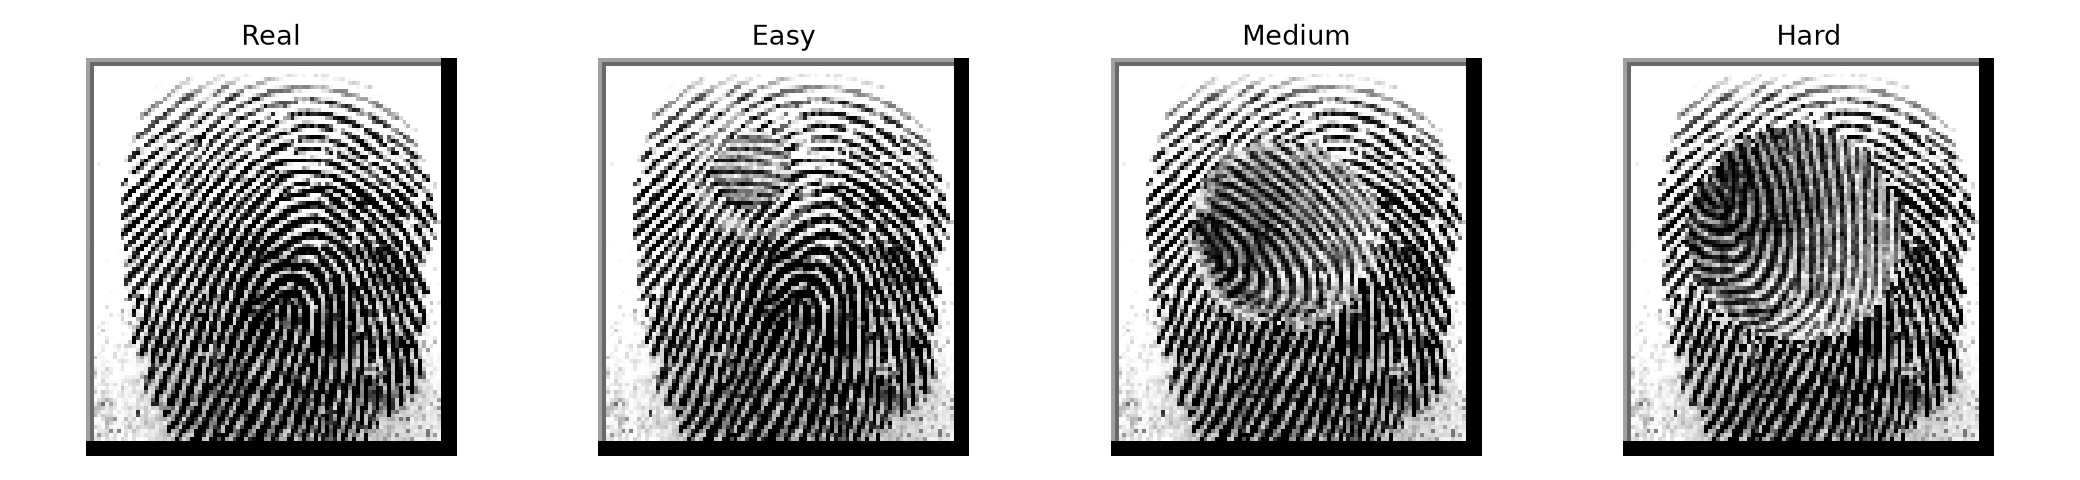

In [3]:
display(results["inventory"])
display(DisplayImage(filename=str(results["output_dir"] / "notebook_dataset_inventory.png")))

## 4. Preprocessing and Controlled Degradation

,IMAGE_SIZE,SEED,NOISE_SEED_BASE,CONTROLLED_SEVERITY,GAUSSIAN_SIGMA,FINAL_NLM_H,NLM_TEMPLATE_WINDOW_SIZE,NLM_SEARCH_WINDOW_SIZE
0,"(256, 256)",20260902,20260903,0.55,0.04825,0.06,7,21


,candidate,mse,psnr,ssim,coherence,local_contrast,fragmentation
0,P0 degraded,0.001959,27.080727,0.901824,0.693243,0.230553,4.399456
1,NLM enhanced,0.001246,29.046038,0.942726,0.784692,0.224232,3.076263


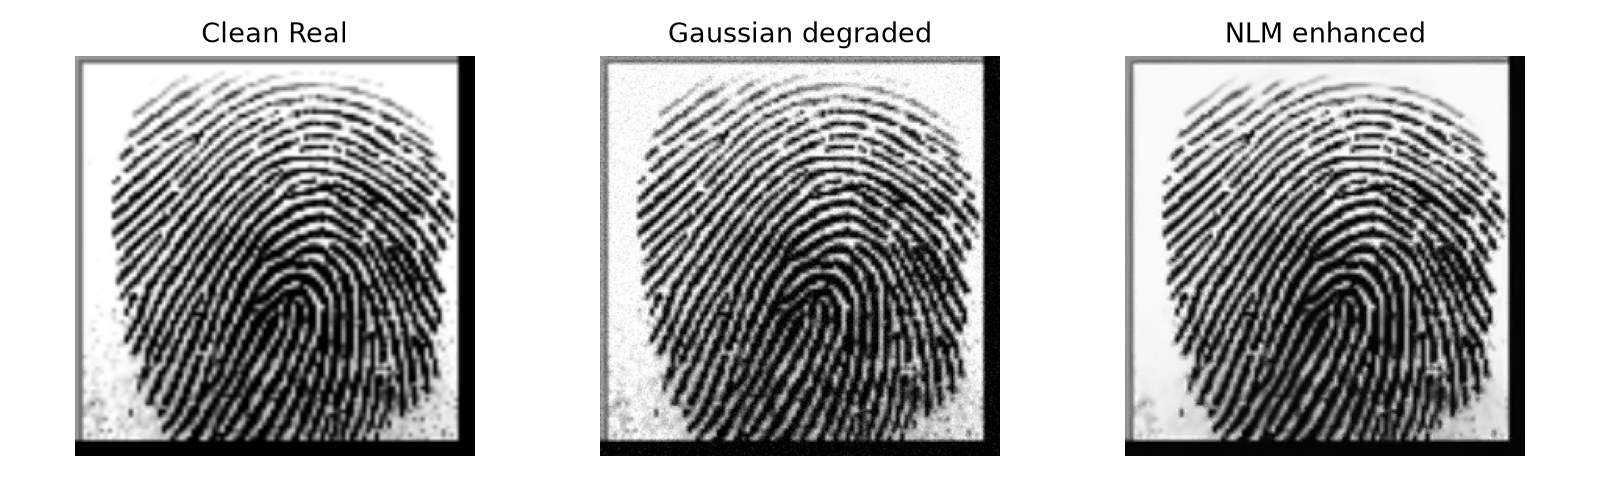

In [4]:
display(pd.DataFrame([{
    "IMAGE_SIZE": str(IMAGE_SIZE),
    "SEED": SEED,
    "NOISE_SEED_BASE": NOISE_SEED_BASE,
    "CONTROLLED_SEVERITY": CONTROLLED_SEVERITY,
    "GAUSSIAN_SIGMA": GAUSSIAN_SIGMA,
    "FINAL_NLM_H": FINAL_NLM_H,
    "NLM_TEMPLATE_WINDOW_SIZE": NLM_TEMPLATE_WINDOW_SIZE,
    "NLM_SEARCH_WINDOW_SIZE": NLM_SEARCH_WINDOW_SIZE,
}]))
display(results["demo_metrics"])
display(DisplayImage(filename=str(results["output_dir"] / "notebook_representative_real_enhancement.png")))

## 5. Conventional Baselines

In [5]:
baseline_methods = ["gaussian", "median", "clahe", "contrast_stretching", "ordinary_gabor", "wiener"]
display(pd.DataFrame({"comparator_only_baseline": baseline_methods}))

,comparator_only_baseline
0,gaussian
1,median
2,clahe
3,contrast_stretching
4,ordinary_gabor
5,wiener


## 6. Member 1 - Non-Local Means Denoising

In [6]:
display(results["member_summary"].query("method == 'M1 NLM'"))

,method,images,PSNR_mean,PSNR_std,MSE_mean,MSE_std,SSIM_mean,SSIM_std
0,M1 NLM,12,29.436598,0.645713,0.00115,0.000164,0.940786,0.014882


## 7. Member 2 - Modified Orientation-Adaptive Gabor Filtering

In [7]:
display(results["member_summary"].query("method == 'M2 Modified Gabor'"))

,method,images,PSNR_mean,PSNR_std,MSE_mean,MSE_std,SSIM_mean,SSIM_std
3,M2 Modified Gabor,12,25.000204,0.586853,0.003188,0.000425,0.83731,0.042086


## 8. Member 3 - Total Variation Restoration

In [8]:
display(results["member_summary"].query("method == 'M3 TV'"))

,method,images,PSNR_mean,PSNR_std,MSE_mean,MSE_std,SSIM_mean,SSIM_std
1,M3 TV,12,29.185022,0.562663,0.001215,0.000151,0.940203,0.011314


## 9. Member 4 - Coherence-Guided Directional Diffusion

In [9]:
display(results["member_summary"].query("method == 'M4 Directional Diffusion'"))

,method,images,PSNR_mean,PSNR_std,MSE_mean,MSE_std,SSIM_mean,SSIM_std
2,M4 Directional Diffusion,12,27.80275,0.697469,0.001678,0.00027,0.868357,0.036982


## 10. Technique Comparison

,method,images,PSNR_mean,PSNR_std,MSE_mean,MSE_std,SSIM_mean,SSIM_std
0,M1 NLM,12,29.436598,0.645713,0.001150,0.000164,0.940786,0.014882
1,M3 TV,12,29.185022,0.562663,0.001215,0.000151,0.940203,0.011314
2,M4 Directional Diffusion,12,27.802750,0.697469,0.001678,0.000270,0.868357,0.036982
3,M2 Modified Gabor,12,25.000204,0.586853,0.003188,0.000425,0.837310,0.042086


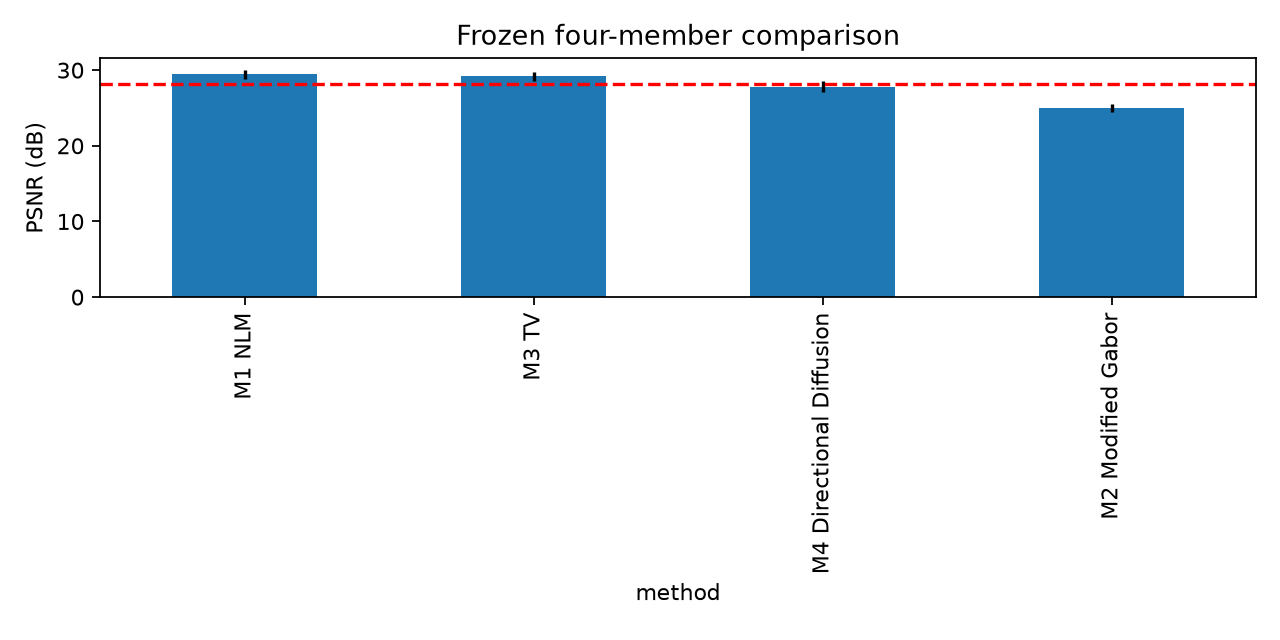

In [10]:
display(results["member_summary"])
display(DisplayImage(filename=str(results["output_dir"] / "notebook_member_comparison_psnr.png")))

## 11. Compatibility and Hybrid Investigation

,candidate,images,PSNR_mean,PSNR_std,MSE_mean,SSIM_mean
0,C0 NLM,12,29.436598,0.645713,0.001150,0.940786
1,C1 TV -> NLM,12,28.943611,0.346102,0.001279,0.928609
2,C3 NLM -> Directional Diffusion,12,28.296774,0.953702,0.001512,0.932011
3,C4 TV -> NLM -> Directional Diffusion,12,26.609861,0.970276,0.002233,0.910567
4,C2 NLM -> Modified Gabor,12,25.227698,0.809450,0.003047,0.909122


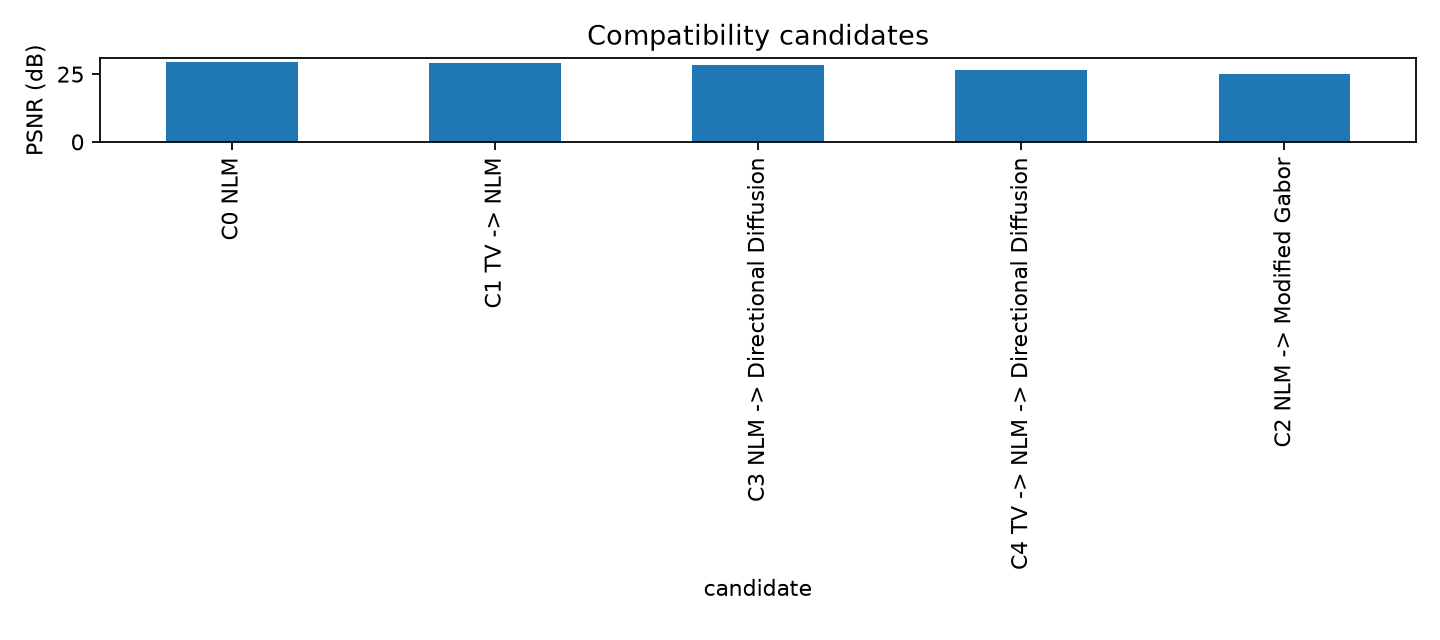

In [11]:
display(results["compat_summary"])
display(DisplayImage(filename=str(results["output_dir"] / "notebook_compatibility_psnr.png")))

## 12. Final Enhancement Pipeline

In [12]:
selected = results["selected_candidate"]
assert selected == "C0 NLM"
display(Markdown(f"Selected final grayscale pipeline: **NLM h={FINAL_NLM_H:.2f}**. Compatibility winner: **{selected}**."))

Selected final grayscale pipeline: **NLM h=0.06**. Compatibility winner: **C0 NLM**.

## 13. PSNR, MSE, and SSIM Evaluation

In [13]:
metric_columns = [
    "degraded_mse", "degraded_psnr", "degraded_ssim",
    "enhanced_mse", "enhanced_psnr", "enhanced_ssim",
    "delta_mse", "delta_psnr", "delta_ssim",
]
display(results["holdout_results"][["filename", "noise_seed", *metric_columns]].head())
display(results["holdout_summary"])

,filename,noise_seed,degraded_mse,degraded_psnr,degraded_ssim,enhanced_mse,enhanced_psnr,enhanced_ssim,delta_mse,delta_psnr,delta_ssim
0,586__M_Right_middle_finger.BMP,20260903,0.001930,27.144917,0.911032,0.001220,29.137630,0.948255,-0.000710,1.992712,0.037224
1,541__M_Left_thumb_finger.BMP,20260904,0.001742,27.590592,0.821522,0.001022,29.907418,0.950389,-0.000720,2.316825,0.128868
2,15__F_Left_little_finger.BMP,20260905,0.001644,27.840926,0.733232,0.000734,31.343564,0.963138,-0.000910,3.502638,0.229905
3,586__M_Left_little_finger.BMP,20260906,0.001882,27.254669,0.868663,0.001195,29.225824,0.946161,-0.000686,1.971155,0.077498
4,176__M_Left_index_finger.BMP,20260907,0.001971,27.053009,0.897595,0.001327,28.770340,0.945238,-0.000644,1.717331,0.047642


,degraded_psnr,enhanced_psnr,enhanced_mse,enhanced_ssim,delta_psnr,delta_mse,delta_ssim
mean,27.387560,29.644319,0.001098,0.938317,2.256759,-0.00073,0.103454
std,0.260277,0.675750,NaN,NaN,NaN,NaN,NaN
median,NaN,29.615992,NaN,NaN,NaN,NaN,NaN
min,NaN,28.051874,NaN,NaN,NaN,NaN,NaN
max,NaN,31.851554,NaN,NaN,NaN,NaN,NaN


## 14. Ridge and Quality Metrics

In [14]:
display(results["structural_sample"])
display(results["altered_summary"][[
    "severity", "count", "mean_delta_coherence", "mean_delta_contrast",
    "mean_delta_fragmentation", "mean_delta_continuity", "mean_delta_ridge_coverage",
]])

,image,coherence,contrast,fragmentation,continuity,ridge_coverage
0,100__M_Left_index_finger.BMP,0.770669,0.229565,2.858674,31.8,0.427017


,severity,count,mean_delta_coherence,mean_delta_contrast,mean_delta_fragmentation,mean_delta_continuity,mean_delta_ridge_coverage
0,Easy,500,0.054444,-0.005166,-1.089141,5.184393,-0.004588
1,Medium,500,0.057070,-0.005683,-1.189242,3.992570,-0.004901
2,Hard,500,0.060220,-0.006133,-1.345099,4.010834,-0.005529
3,Overall,1500,0.057245,-0.005661,-1.207827,4.395933,-0.005006


## 15. 100-Image Holdout Validation

In [15]:
holdout = results["holdout_results"]
assert len(holdout) == 100
print(f"Above 28.17 dB: {int(holdout.above_28_17.sum())}/{len(holdout)}")
display(holdout.describe(include="all"))

Above 28.17 dB: 99/100


,filename,noise_seed,degraded_mse,degraded_psnr,degraded_ssim,enhanced_mse,enhanced_psnr,enhanced_ssim,delta_mse,delta_psnr,delta_ssim,above_28_17
count,100,1.000000e+02,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100
unique,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,586__M_Right_middle_finger.BMP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99
mean,NaN,2.026095e+07,0.001828,27.387560,0.834863,0.001098,29.644319,0.938317,-0.000730,2.256759,0.103454,NaN
std,NaN,2.901149e+01,0.000108,0.260277,0.050666,0.000167,0.675750,0.023008,0.000137,0.572432,0.048858,NaN
min,NaN,2.026090e+07,0.001523,26.793281,0.679842,0.000653,28.051874,0.817064,-0.001239,1.107328,0.011821,NaN
25%,NaN,2.026093e+07,0.001751,27.212658,0.805753,0.000989,29.147347,0.934187,-0.000775,1.896110,0.063920,NaN
50%,NaN,2.026095e+07,0.001844,27.343033,0.835799,0.001092,29.615992,0.944624,-0.000712,2.150238,0.099979,NaN
75%,NaN,2.026098e+07,0.001900,27.567195,0.873147,0.001217,30.048214,0.951952,-0.000648,2.504011,0.135440,NaN


## 16. 500-Image Robustness Validation

In [16]:
large = results["large_results"]
assert len(large) == 500
display(results["large_summary"])
print(f"Controlled 500-image mean margin over 28.17 dB: {results['large_stats']['margin_to_benchmark']:+.4f} dB")

,count,mean_psnr,std_psnr,median_psnr,min_psnr,max_psnr,mean_mse,mean_ssim,above_28_17,percentage_above_28_17,margin_to_benchmark
0,500,29.630294,0.62464,29.571109,28.417826,31.746032,0.0011,0.935714,500,100.0,1.460294


Controlled 500-image mean margin over 28.17 dB: +1.4603 dB


## 17. 1500 Altered-Image Validation

,severity,count,mean_coherence_before,mean_contrast_before,mean_fragmentation_before,mean_continuity_before,mean_ridge_coverage_before,mean_coherence_after,mean_contrast_after,mean_fragmentation_after,mean_continuity_after,mean_ridge_coverage_after,mean_delta_coherence,mean_delta_contrast,mean_delta_fragmentation,mean_delta_continuity,mean_delta_ridge_coverage
0,Easy,500,0.659323,0.185714,4.474201,26.026835,0.374696,0.713767,0.180548,3.385060,31.211228,0.370108,0.054444,-0.005166,-1.089141,5.184393,-0.004588
1,Medium,500,0.655751,0.183118,5.264776,21.546367,0.369699,0.712821,0.177435,4.075534,25.538938,0.364798,0.057070,-0.005683,-1.189242,3.992570,-0.004901
2,Hard,500,0.651222,0.179093,5.729496,19.616294,0.363381,0.711442,0.172960,4.384397,23.627128,0.357852,0.060220,-0.006133,-1.345099,4.010834,-0.005529
3,Overall,1500,0.655432,0.182642,5.156158,22.396499,0.369259,0.712677,0.176981,3.948331,26.792431,0.364253,0.057245,-0.005661,-1.207827,4.395933,-0.005006


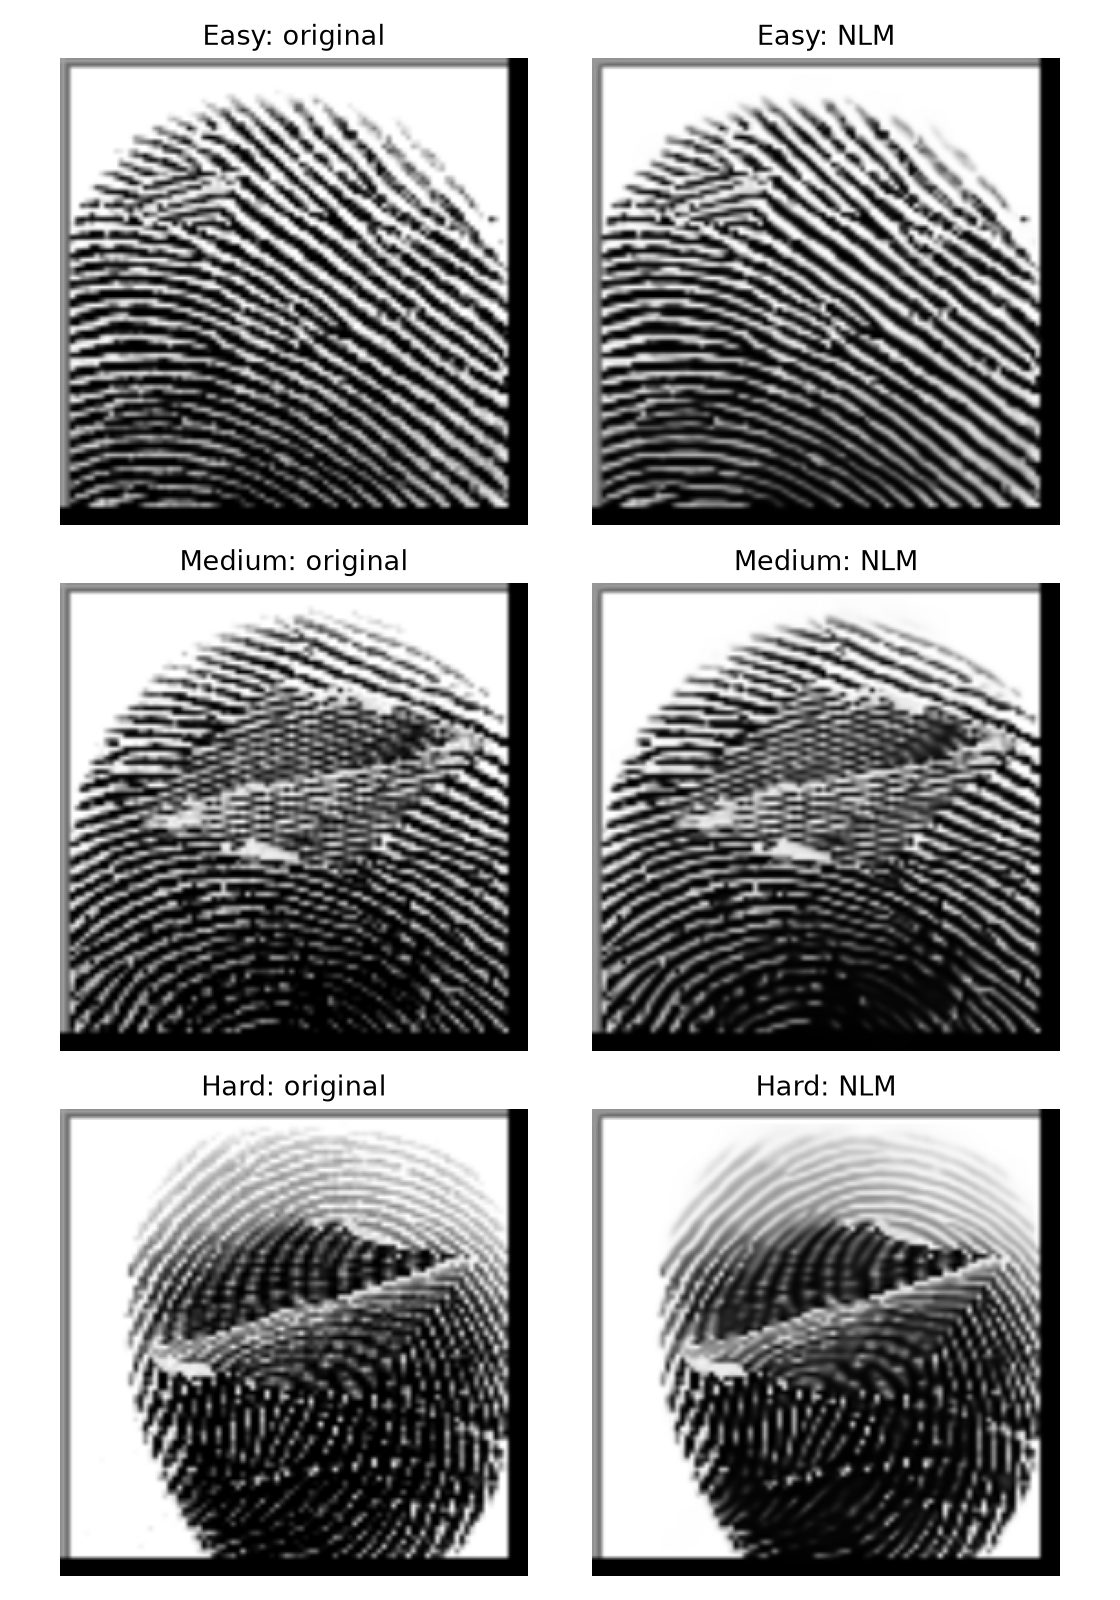

In [17]:
altered = results["altered_results"]
assert len(altered) == 1500
display(results["altered_summary"])
display(DisplayImage(filename=str(results["output_dir"] / "notebook_altered_representatives.png")))

## 18. Result Tables and Exported Outputs

In [18]:
display(results["final_results"])
display(pd.DataFrame([{key: str(value) for key, value in results["saved_tables"].items()}]).T.rename(columns={0: "path"}))

,experiment,result,PSNR_dB,count
0,Member comparison - best,M1 NLM,29.436598,12
1,Compatibility - best,C0 NLM,29.436598,12
2,Fresh holdout,99/100 above 28.17,29.644319,100
3,Final robustness,500/500 above 28.17,29.630294,500
4,Original Altered,delta_coh=+0.05724; delta_frag=-1.20783; delta...,NaN,1500


,path
dataset_inventory,C:\Users\Acer\Documents\GitHub\ImageProcessing...
demo_metrics,C:\Users\Acer\Documents\GitHub\ImageProcessing...
structural_sample,C:\Users\Acer\Documents\GitHub\ImageProcessing...
member_per_image,C:\Users\Acer\Documents\GitHub\ImageProcessing...
member_summary,C:\Users\Acer\Documents\GitHub\ImageProcessing...
compat_per_image,C:\Users\Acer\Documents\GitHub\ImageProcessing...
compat_summary,C:\Users\Acer\Documents\GitHub\ImageProcessing...
holdout_per_image,C:\Users\Acer\Documents\GitHub\ImageProcessing...
holdout_summary,C:\Users\Acer\Documents\GitHub\ImageProcessing...
large_per_image,C:\Users\Acer\Documents\GitHub\ImageProcessing...


## 19. Result Plots

In [19]:
display(pd.DataFrame({"figure_path": [str(path) for path in results["saved_figures"]]}))

,figure_path
0,C:\Users\Acer\Documents\GitHub\ImageProcessing...
1,C:\Users\Acer\Documents\GitHub\ImageProcessing...
2,C:\Users\Acer\Documents\GitHub\ImageProcessing...
3,C:\Users\Acer\Documents\GitHub\ImageProcessing...
4,C:\Users\Acer\Documents\GitHub\ImageProcessing...


## 20. Final Ranking and Selected Configuration

In [20]:
ranking = results["member_summary"][["method", "PSNR_mean", "MSE_mean", "SSIM_mean"]].copy()
ranking["rank"] = range(1, len(ranking) + 1)
display(ranking)
display(results["compat_summary"][["candidate", "PSNR_mean", "MSE_mean", "SSIM_mean"]])
display(Markdown(f"Final selected configuration: **NLM h={FINAL_NLM_H:.2f}**."))

,method,PSNR_mean,MSE_mean,SSIM_mean,rank
0,M1 NLM,29.436598,0.001150,0.940786,1
1,M3 TV,29.185022,0.001215,0.940203,2
2,M4 Directional Diffusion,27.802750,0.001678,0.868357,3
3,M2 Modified Gabor,25.000204,0.003188,0.837310,4


,candidate,PSNR_mean,MSE_mean,SSIM_mean
0,C0 NLM,29.436598,0.001150,0.940786
1,C1 TV -> NLM,28.943611,0.001279,0.928609
2,C3 NLM -> Directional Diffusion,28.296774,0.001512,0.932011
3,C4 TV -> NLM -> Directional Diffusion,26.609861,0.002233,0.910567
4,C2 NLM -> Modified Gabor,25.227698,0.003047,0.909122


Final selected configuration: **NLM h=0.06**.

## 21. Equivalence Probe

In [21]:
display(results["equivalence_probe"])
print(results["output_dir"] / "notebook_equivalence_arrays.npz")

,filename,mse,psnr,ssim
0,100__M_Left_index_finger.BMP,0.001240,29.064950,0.944228
1,100__M_Left_little_finger.BMP,0.001101,29.581654,0.945159
2,100__M_Left_middle_finger.BMP,0.001348,28.703501,0.943040


C:\Users\Acer\Documents\GitHub\ImageProcessing\Fingerprint_Enhancement_Jupyter_Project\Fingerprint_Enhancement_Jupyter_Project\Fingerprint_Enhancement_Project\outputs\notebook_equivalence_arrays.npz


## 22. Conclusion

In [22]:
overall_alt = results["altered_summary"].query("severity == 'Overall'").iloc[0]
large_stats = results["large_stats"]
holdout = results["holdout_results"]
display(Markdown(
    f"The recomputed evidence selects **NLM h={FINAL_NLM_H:.2f}** as the final grayscale method. "
    f"It led the frozen member and compatibility comparisons, regenerated "
    f"**{holdout.enhanced_psnr.mean():.4f} dB** on the 100-image holdout, and achieved "
    f"**{large_stats['mean_psnr']:.4f} dB** over 500 Real images "
    f"({large_stats['above_28_17']}/500 above 28.17 dB). The unpaired Altered evaluation "
    f"processed 1,500 originals and showed coherence, fragmentation, and contrast deltas of "
    f"**{overall_alt.mean_delta_coherence:+.5f}**, "
    f"**{overall_alt.mean_delta_fragmentation:+.5f}**, and "
    f"**{overall_alt.mean_delta_contrast:+.5f}**, respectively. Structural processing remains optional and downstream."
))

The recomputed evidence selects **NLM h=0.06** as the final grayscale method. It led the frozen member and compatibility comparisons, regenerated **29.6443 dB** on the 100-image holdout, and achieved **29.6303 dB** over 500 Real images (500/500 above 28.17 dB). The unpaired Altered evaluation processed 1,500 originals and showed coherence, fragmentation, and contrast deltas of **+0.05724**, **-1.20783**, and **-0.00566**, respectively. Structural processing remains optional and downstream.